# Experiment Summary
This notebook visualizes and summarizes a single C++ HTM experiment run (ROC/threshold sweep, CPU/RAM time series, latency, metrics). Adjust `EXP_DIR` below to point to another run folder if needed.

In [2]:
# Paths and imports (adjust EXP_DIR to analyze another run)
import os
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Candidate experiment directories (edit the first entry to point to any other run)
EXP_DIR_CANDIDATES = [
    Path('results/experiments_cpp_naive_20260108_184416_414'),  # project-root relative
    Path('.')  # notebook folder (works when the notebook sits inside the run directory)
]

EXP_DIR = None
for candidate in EXP_DIR_CANDIDATES:
    candidate = candidate.resolve()
    if (candidate / 'model_performance_metrics.json').exists():
        EXP_DIR = candidate
        break

if EXP_DIR is None:
    raise FileNotFoundError('Could not locate experiment directory; update EXP_DIR_CANDIDATES.')

PERF_PATH = EXP_DIR / 'model_performance_metrics.json'
EFF_PATH  = EXP_DIR / 'model_efficiency_metrics.json'
ROC_PATH  = EXP_DIR / 'roc_thresholds.json'
SCORES_PATH = EXP_DIR / 'anomaly_scores.csv'

with PERF_PATH.open() as f:
    perf = json.load(f)
with EFF_PATH.open() as f:
    eff = json.load(f)
with ROC_PATH.open() as f:
    roc = json.load(f)

scores_df = pd.read_csv(SCORES_PATH) if SCORES_PATH.exists() else pd.DataFrame()

# Build metrics table (best vs average)
best = perf.get('best', {})
avg  = perf.get('average', {})
metrics_df = pd.DataFrame([
    {
        'view': 'best threshold',
        'threshold': best.get('threshold', np.nan),
        'f1': best.get('f1', np.nan),
        'precision': best.get('precision', np.nan),
        'recall': best.get('recall', np.nan),
        'accuracy': best.get('accuracy', np.nan)
    },
    {
        'view': 'average (all thresholds)',
        'threshold': np.nan,
        'f1': avg.get('f1', np.nan),
        'precision': avg.get('precision', np.nan),
        'recall': avg.get('recall', np.nan),
        'accuracy': avg.get('accuracy', np.nan)
    }
])
metrics_df

,view,threshold,f1,precision,recall,accuracy
0,best threshold,0.97,0.870312,1.000000,0.770400,0.988520
1,average (all thresholds),NaN,0.163632,0.109186,0.983279,0.270333


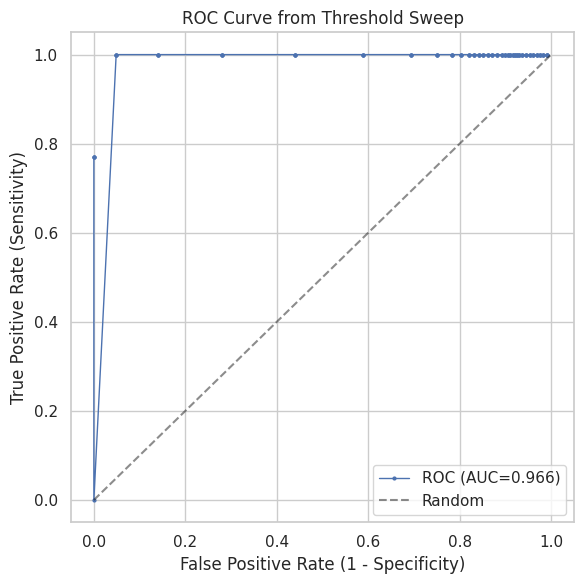

np.float64(0.96589)

In [4]:
# ROC curve from roc_thresholds.json (TPR vs FPR) and AUC
roc_df = pd.DataFrame(roc.get('thresholds', []))
if 'specificity' in roc_df and 'sensitivity' in roc_df:
    roc_df['fpr'] = 1.0 - roc_df['specificity']
    roc_df['tpr'] = roc_df['sensitivity']
    roc_df = roc_df.sort_values('fpr').reset_index(drop=True)
    if hasattr(np, 'trapezoid'):
        auc = np.trapezoid(y=roc_df['tpr'].values, x=roc_df['fpr'].values)
    else:
        auc = np.trapz(y=roc_df['tpr'].values, x=roc_df['fpr'].values)
else:
    roc_df['fpr'] = np.nan
    roc_df['tpr'] = np.nan
    auc = np.nan

plt.figure(figsize=(6, 6))
plt.plot(roc_df['fpr'], roc_df['tpr'], marker='o', markersize=2, linewidth=1, label=f'ROC (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve from Threshold Sweep')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

auc

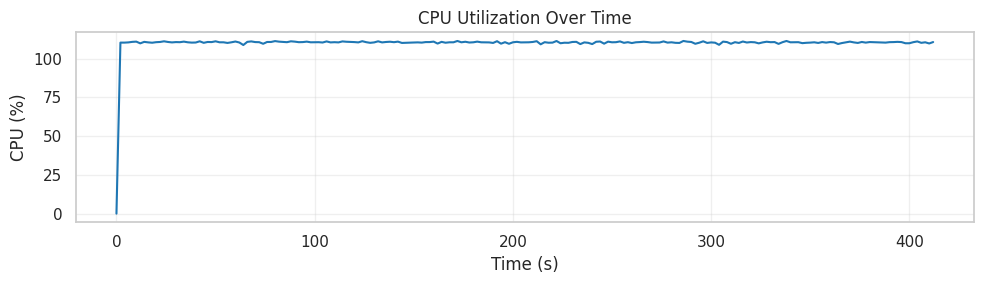

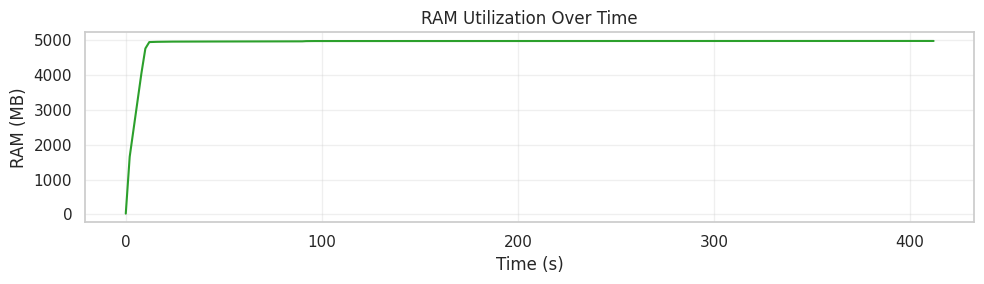

,metric,cpu_percent,ram_mb
0,min,0.000,24.031
1,avg,110.037,4903.507
2,peak,111.443,4973.180


In [5]:
# CPU and RAM time series from efficiency file
samples = eff.get('resource_samples', [])
samples_df = pd.DataFrame(samples)

if not samples_df.empty:
    samples_df['elapsed_s'] = samples_df['elapsed_ms'] / 1000.0

    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    ax.plot(samples_df['elapsed_s'], samples_df['cpu_percent'], color='tab:blue')
    ax.set_title('CPU Utilization Over Time')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('CPU (%)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    ax.plot(samples_df['elapsed_s'], samples_df['ram_mb'], color='tab:green')
    ax.set_title('RAM Utilization Over Time')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('RAM (MB)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No resource_samples captured for this run.')

# CPU/RAM summary table (min/avg/peak)
cpu = eff.get('cpu', {})
ram = eff.get('ram', {})
summary_df = pd.DataFrame({
    'metric': ['min', 'avg', 'peak'],
    'cpu_percent': [cpu.get('min', np.nan), cpu.get('avg', np.nan), cpu.get('peak', np.nan)],
    'ram_mb': [ram.get('min', np.nan), ram.get('avg', np.nan), ram.get('peak', np.nan)]
})
summary_df

/tmp/ipykernel_36064/1012523008.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='stat', y='value_ms', data=lat_df, ax=ax, palette='Blues_d')


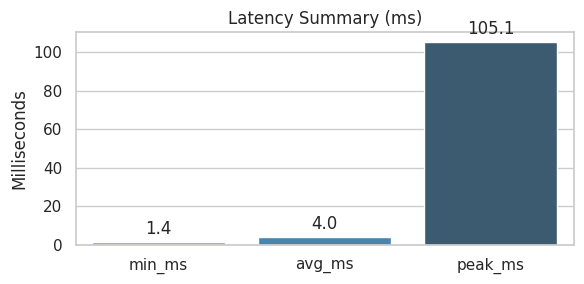

Total runtime: 414072.626 ms = 414.073 s = 6.901 min


,stat,value_ms
0,min_ms,1.423
1,avg_ms,4.007
2,peak_ms,105.117


In [6]:
# Latency summary (min/avg/peak) and total runtime
lat = eff.get('latency', {})
lat_df = pd.DataFrame({
    'stat': ['min_ms', 'avg_ms', 'peak_ms'],
    'value_ms': [lat.get('min_ms', np.nan), lat.get('avg_ms', np.nan), lat.get('peak_ms', np.nan)]
})

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
sns.barplot(x='stat', y='value_ms', data=lat_df, ax=ax, palette='Blues_d')
ax.set_title('Latency Summary (ms)')
ax.set_xlabel('')
ax.set_ylabel('Milliseconds')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)
plt.tight_layout()
plt.show()

# Total runtime conversions
total_ms = eff.get('total_runtime_ms', np.nan)
total_s = total_ms / 1000.0 if not math.isnan(total_ms) else np.nan
total_min = total_s / 60.0 if not math.isnan(total_s) else np.nan
print(f'Total runtime: {total_ms:.3f} ms = {total_s:.3f} s = {total_min:.3f} min')
lat_df

## Notes
- ROC curve is built from per-threshold sensitivity (TPR) and specificity (TNR) with FPR = 1 − specificity.
- CPU/RAM are sampled every ~2 seconds; spikes and averages help assess efficiency.
- Latency shows the per-row processing time summary where available; currently summarized as min/avg/peak.
- Metrics table compares the best operating threshold vs the average across thresholds.

In [7]:
# Final concise summary
best_thr = best.get('threshold', np.nan)
best_f1 = best.get('f1', np.nan)
auc_val = 'N/A' if np.isnan(auc) else f'{auc:.4f}'

cpu_min = cpu.get('min', np.nan)
cpu_avg = cpu.get('avg', np.nan)
cpu_peak = cpu.get('peak', np.nan)
ram_min = ram.get('min', np.nan)
ram_avg = ram.get('avg', np.nan)
ram_peak = ram.get('peak', np.nan)

print('Summary:')
print(f' - Best threshold: {best_thr}')
print(f' - Best F1: {best_f1:.4f}, AUC: {auc_val}')
print(f' - CPU (%) min/avg/peak: {cpu_min:.2f} | {cpu_avg:.2f} | {cpu_peak:.2f}')
print(f' - RAM (MB) min/avg/peak: {ram_min:.2f} | {ram_avg:.2f} | {ram_peak:.2f}')
print(f' - Total runtime: {total_s:.3f} s ({total_min:.3f} min)')

Summary:
 - Best threshold: 0.97
 - Best F1: 0.8703, AUC: 0.9659
 - CPU (%) min/avg/peak: 0.00 | 110.04 | 111.44
 - RAM (MB) min/avg/peak: 24.03 | 4903.51 | 4973.18
 - Total runtime: 414.073 s (6.901 min)
